In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

from scipy.stats import ttest_ind, mannwhitneyu

from src.config import DADOS_ORIGINAIS, DADOS_LIMPOS
from src.graficos import PALETTE

sns.set_theme(palette="bright")

In [2]:
df = pd.read_csv(DADOS_ORIGINAIS)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [6]:
df.describe(exclude="number")

,diagnosis
count,569
unique,2
top,B
freq,357


In [7]:
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [8]:
df["diagnosis"].value_counts(normalize=True)

diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64

In [ ]:
df[df.duplicated()]

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst


In [10]:
df[df.duplicated("id")]

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst


In [11]:
df = df.drop(columns=["id"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [12]:
df = df.reindex(sorted(df.columns), axis=1)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   area_mean                569 non-null    float64
 1   area_se                  569 non-null    float64
 2   area_worst               569 non-null    float64
 3   compactness_mean         569 non-null    float64
 4   compactness_se           569 non-null    float64
 5   compactness_worst        569 non-null    float64
 6   concave points_mean      569 non-null    float64
 7   concave points_se        569 non-null    float64
 8   concave points_worst     569 non-null    float64
 9   concavity_mean           569 non-null    float64
 10  concavity_se             569 non-null    float64
 11  concavity_worst          569 non-null    float64
 12  diagnosis                569 non-null    object 
 13  fractal_dimension_mean   569 non-null    float64
 14  fractal_dimension_se     5

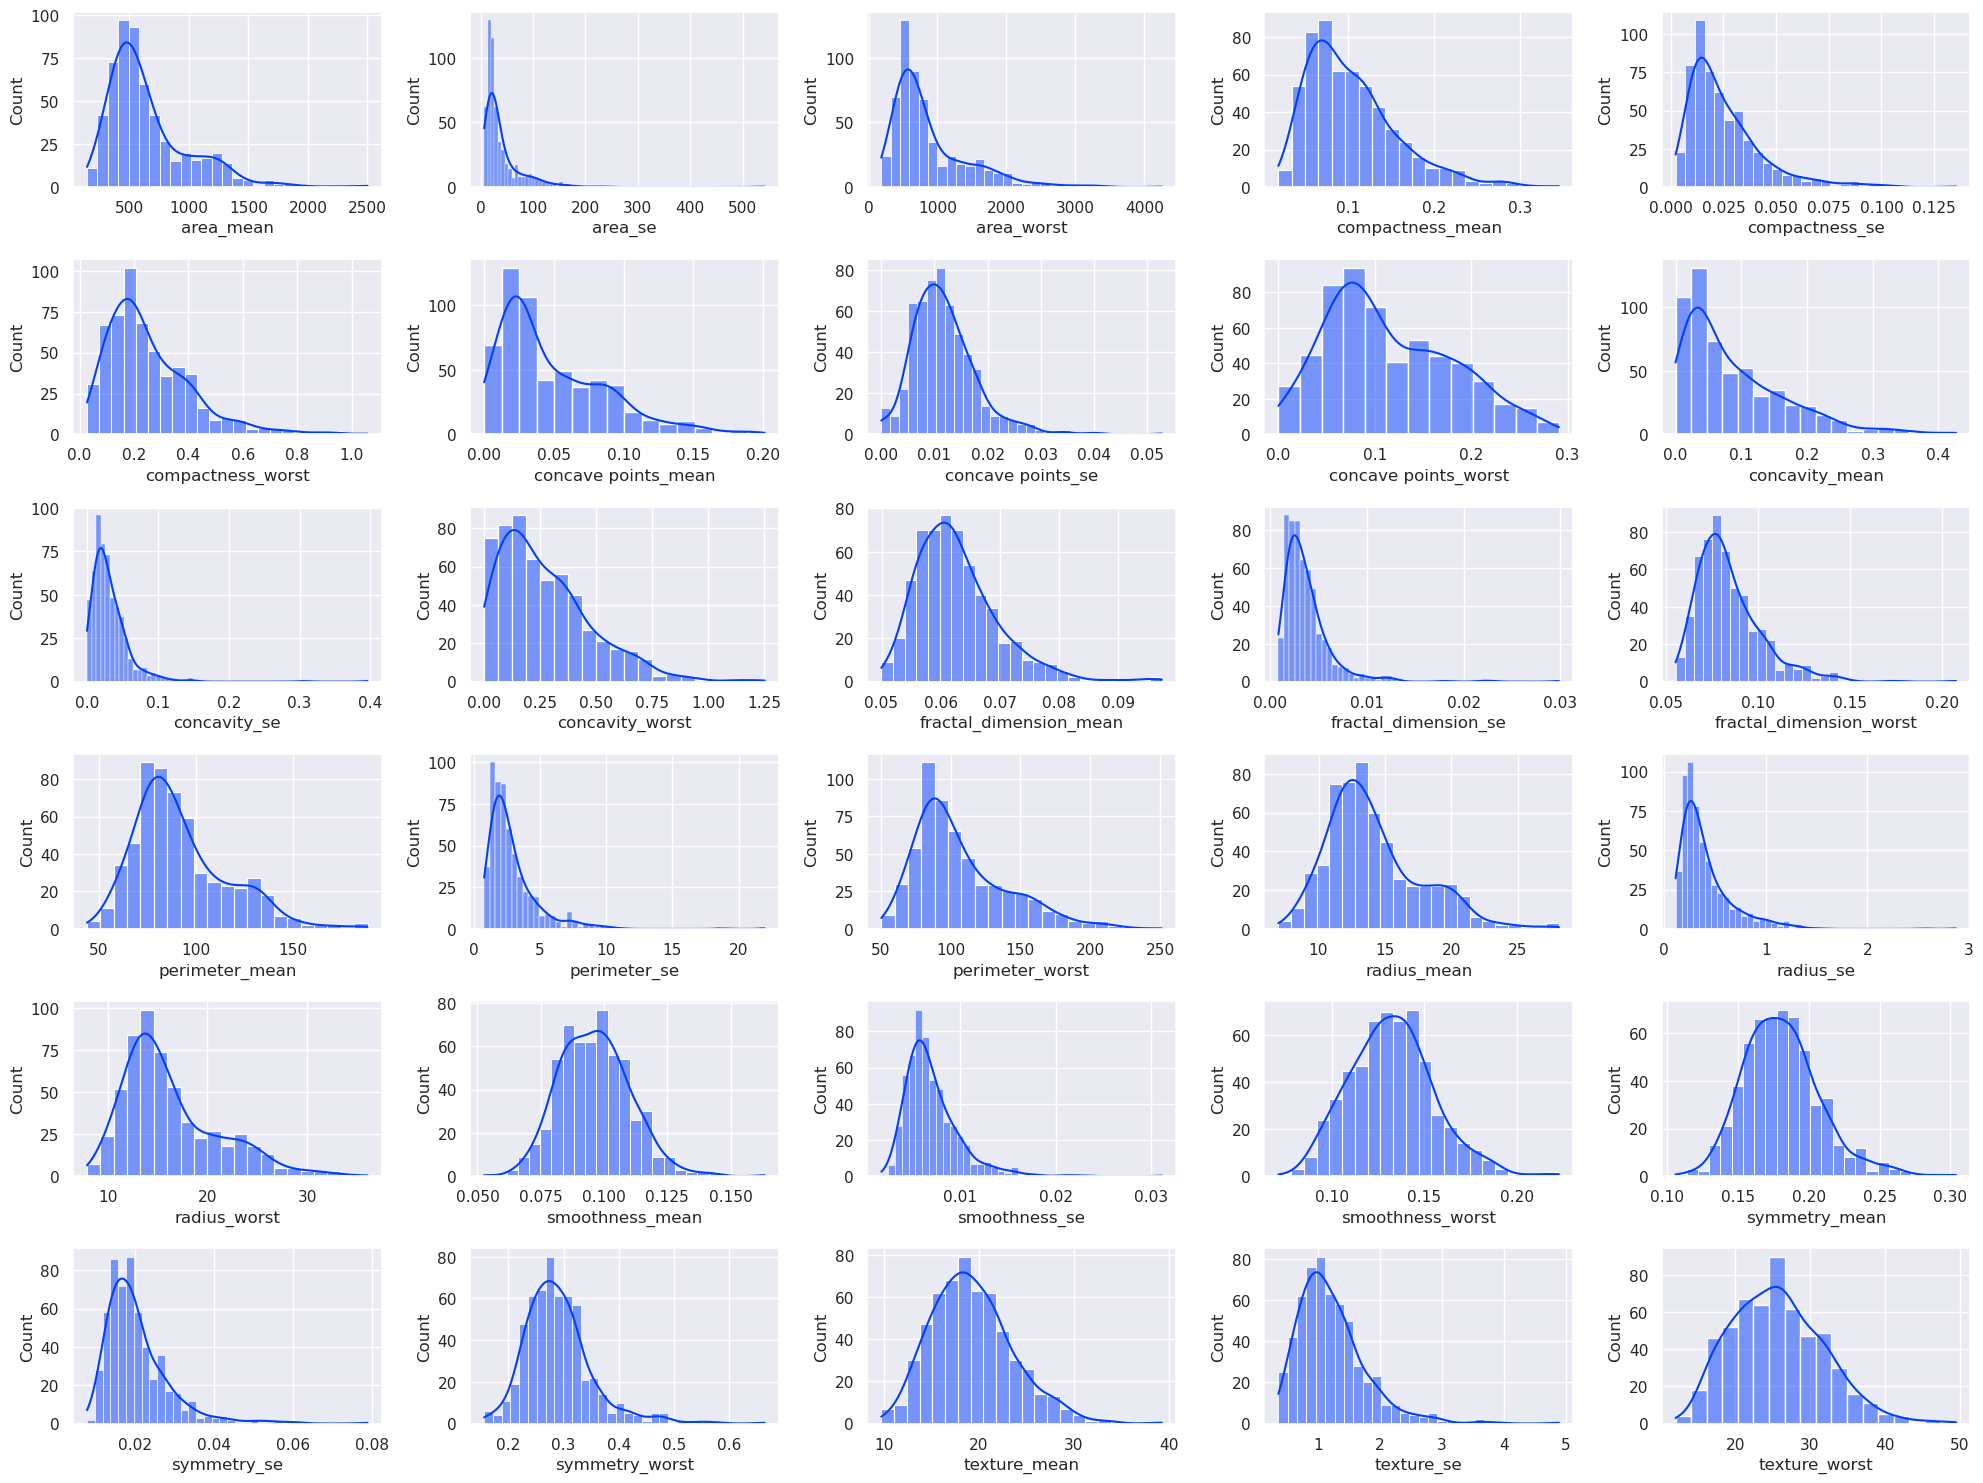

In [14]:
fig, axs = plt.subplots(6, 5, figsize=(20, 15))

for ax, coluna in zip(axs.flatten(), df.select_dtypes("number").columns):
    sns.histplot(x=coluna, ax=ax, data=df, kde=True)

plt.tight_layout()
plt.show()

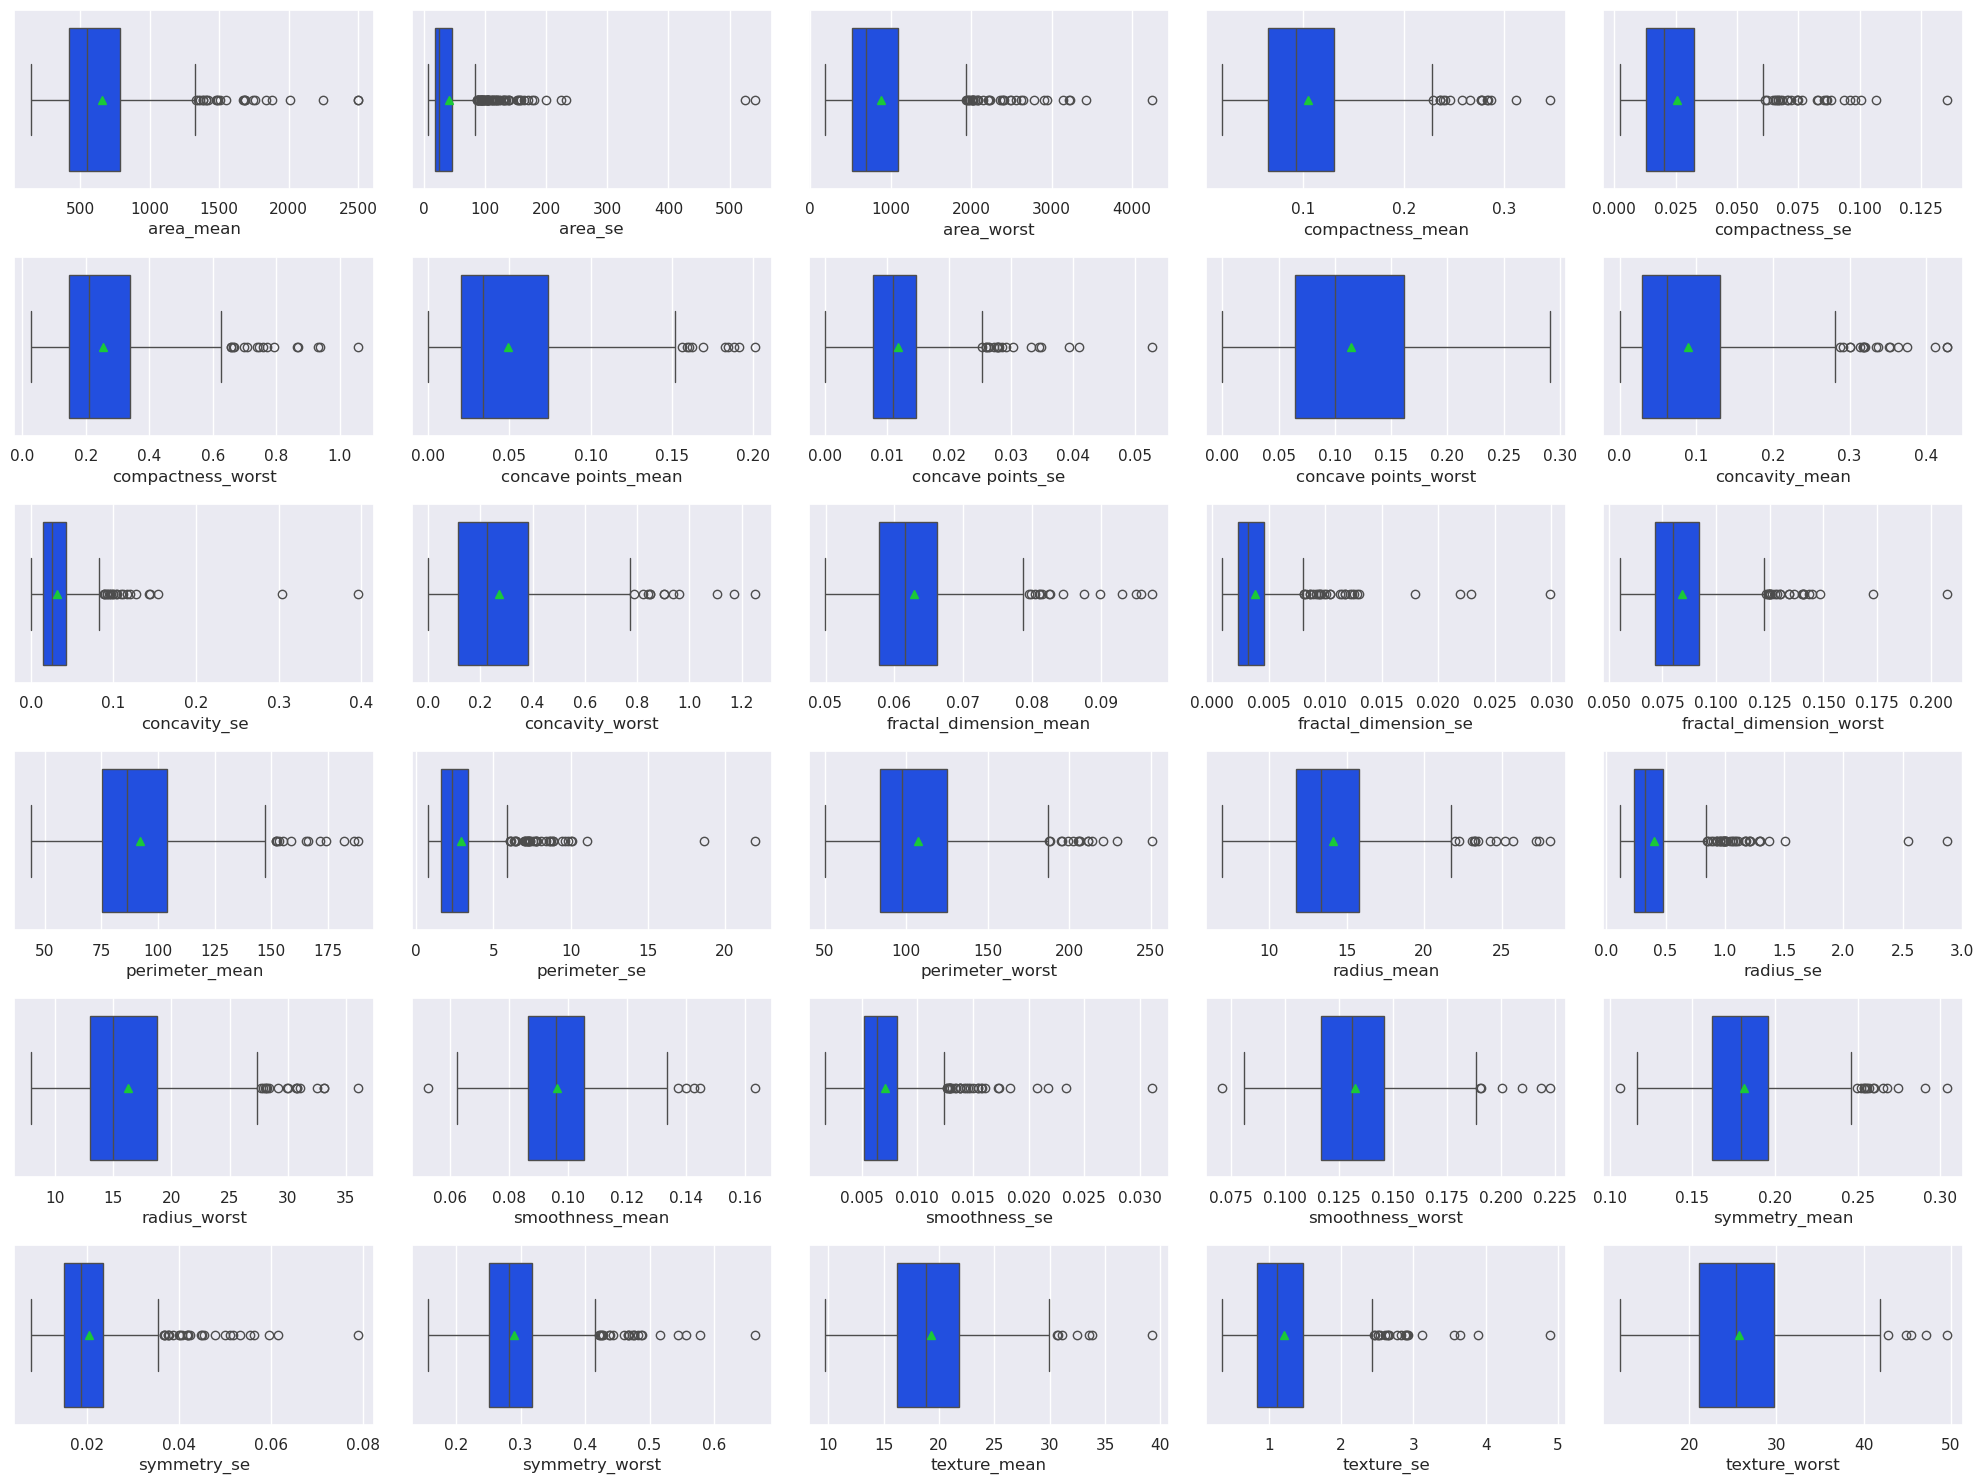

In [16]:
fig, axs = plt.subplots(6, 5, figsize=(20, 15))

for ax, coluna in zip(axs.flatten(), df.select_dtypes("number").columns):
    sns.boxplot(x=coluna, ax=ax, data=df, showmeans=True)

plt.tight_layout()
plt.show()

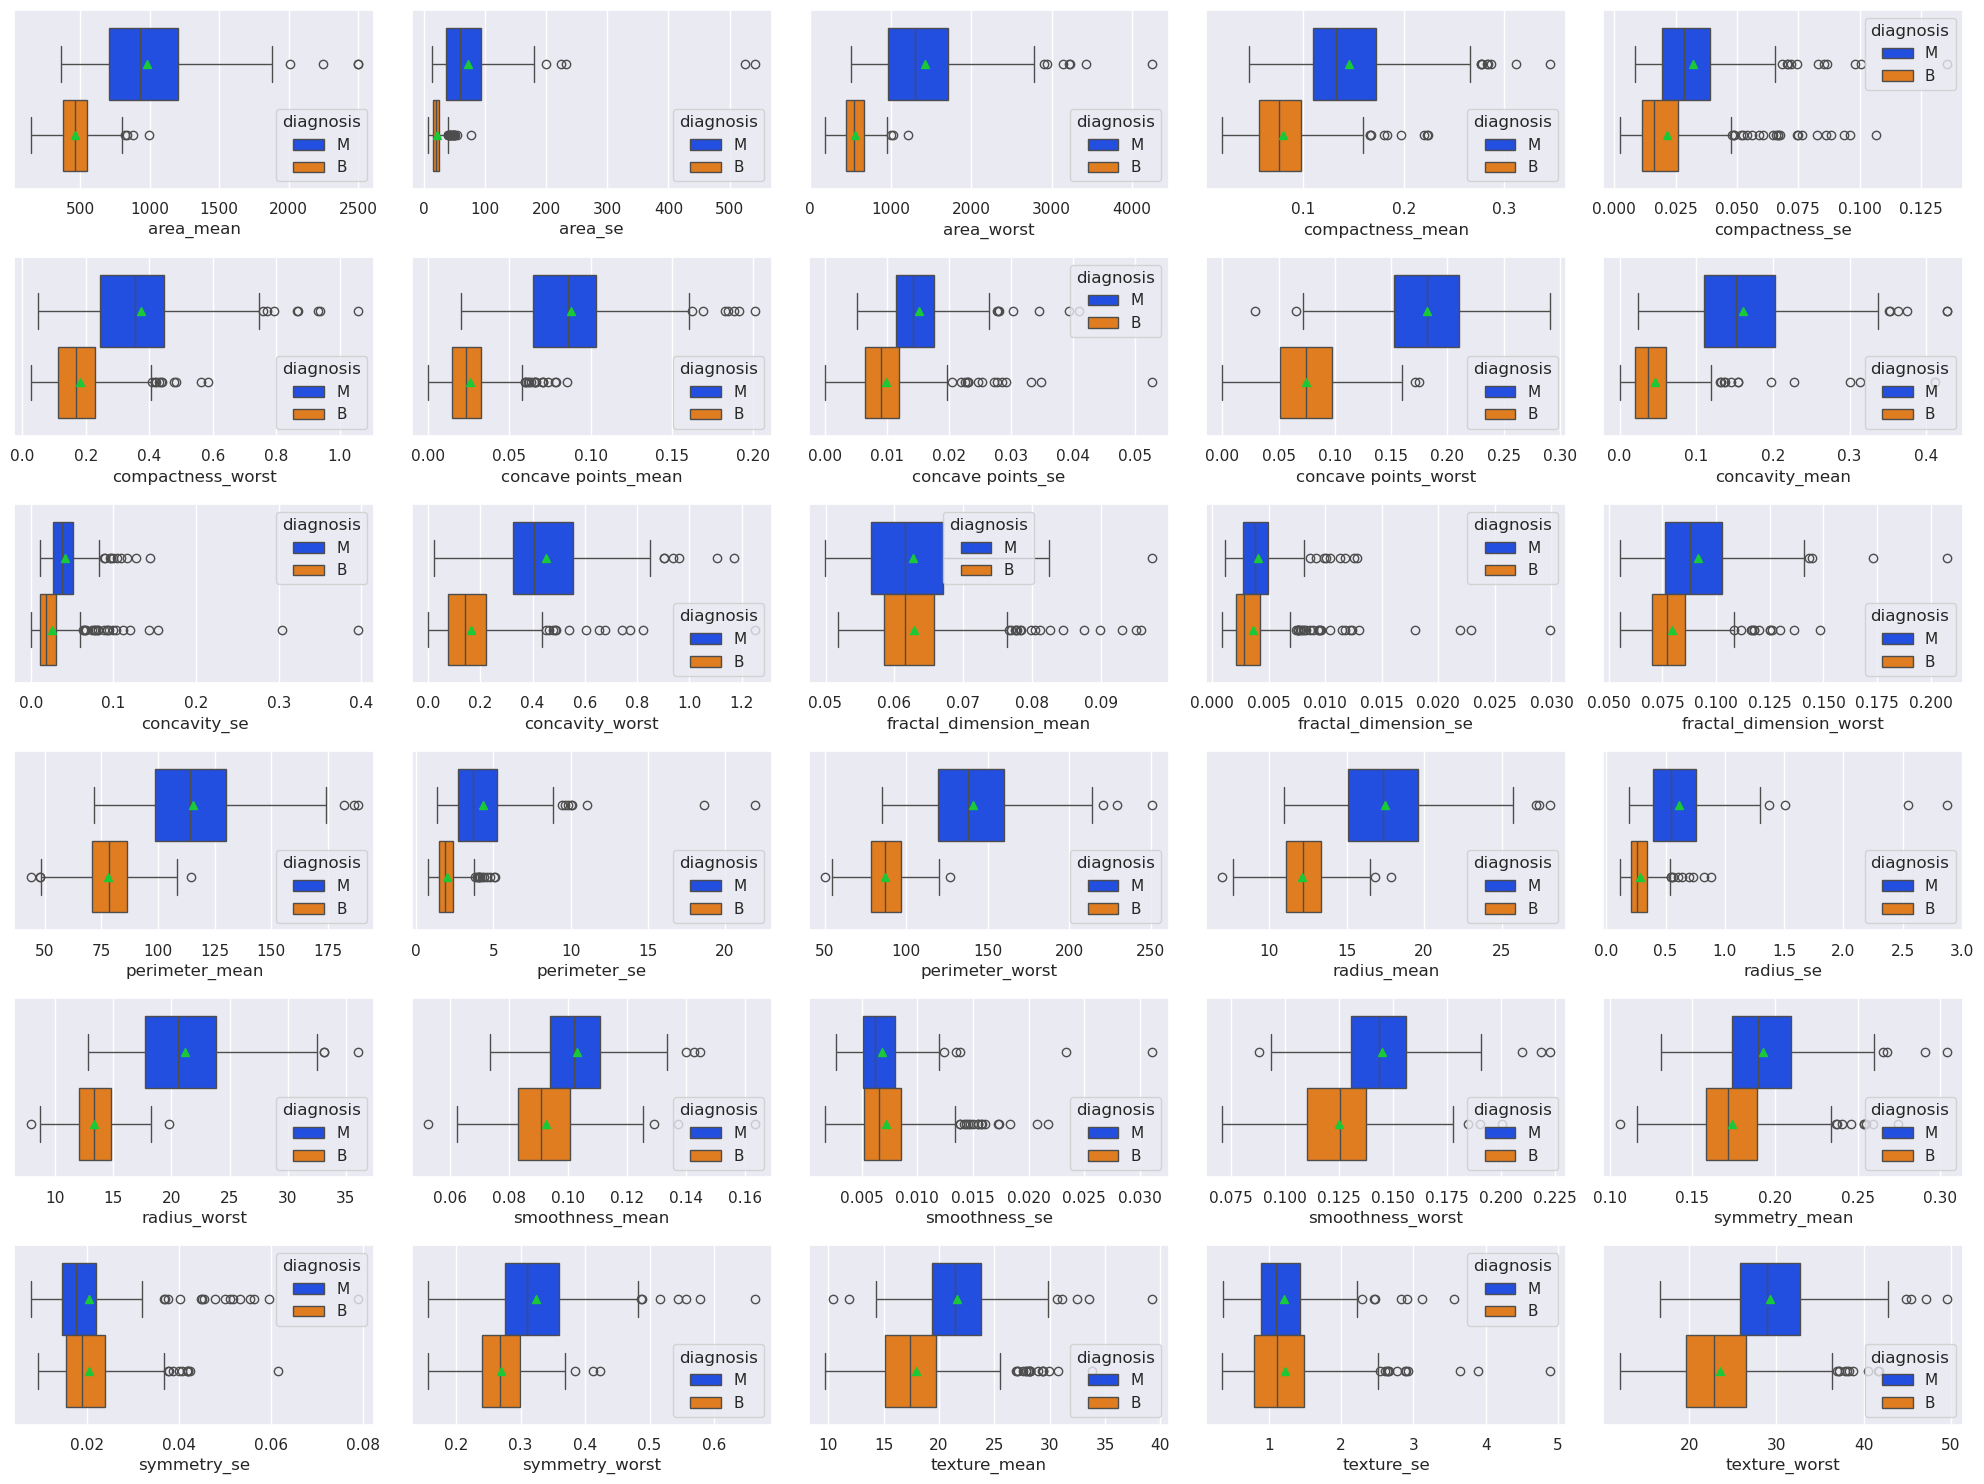

In [18]:
fig, axs = plt.subplots(6, 5, figsize=(20, 15))

for ax, coluna in zip(axs.flatten(), df.select_dtypes("number").columns):
    sns.boxplot(x=coluna, ax=ax, data=df, showmeans=True, hue="diagnosis")

plt.tight_layout()
plt.show()

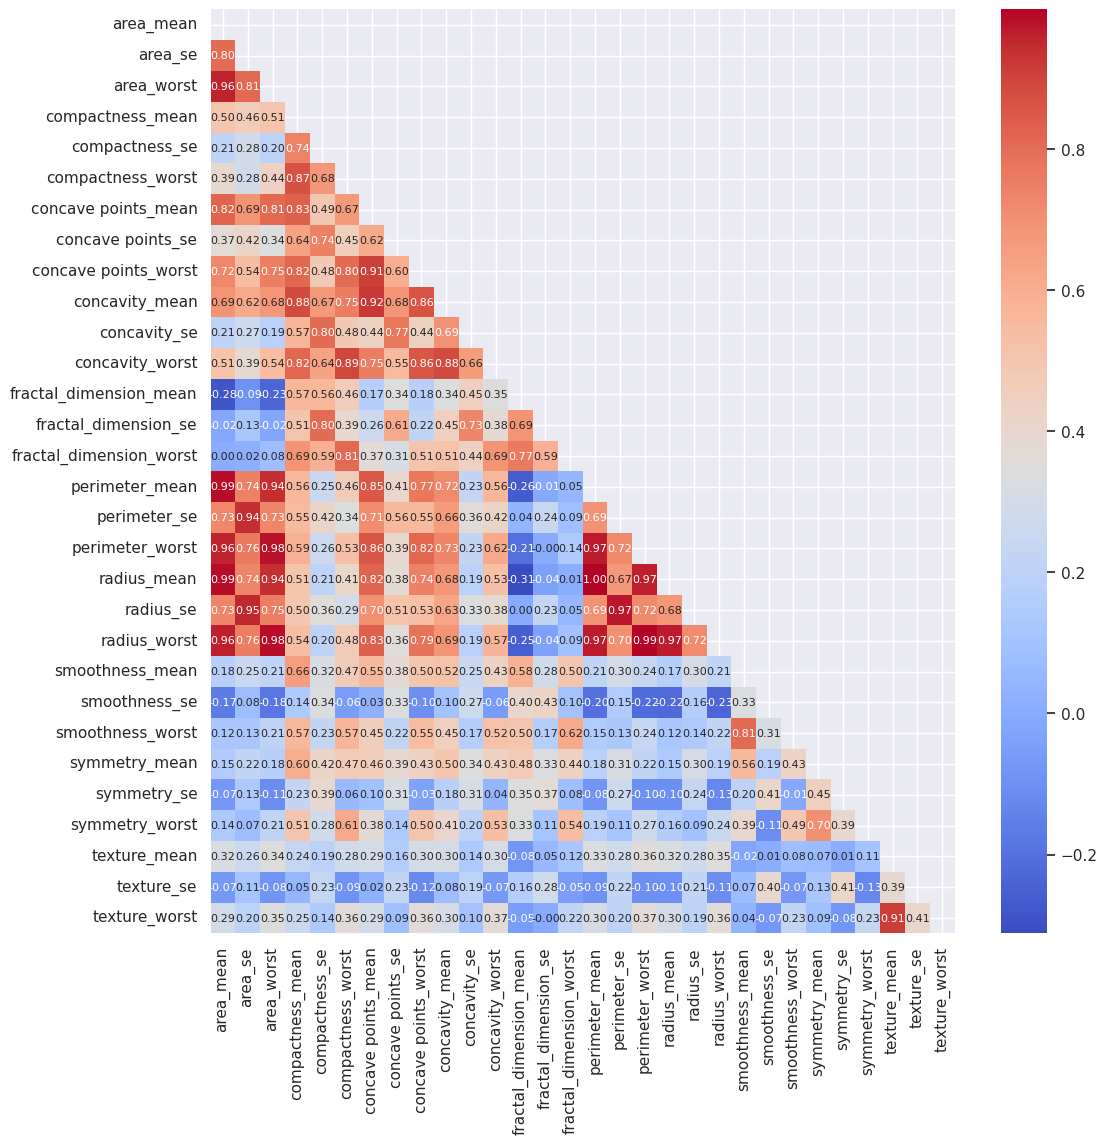

In [21]:
matriz = np.triu(df.select_dtypes("number").corr())

fig, ax = plt.subplots(figsize=(12,12))

sns.heatmap(
    df.select_dtypes("number").corr(),
    mask=matriz,
    annot=True,
    fmt=".2f",
    ax=ax,
    cmap=PALETTE,
    annot_kws={"fontsize": 8}
)

plt.show()


## **Relembrando o Teste t de Student e o Teste de Mann-Whitney U**

No contexto de **classificação binária**, onde temos duas classes (por exemplo, "Positivo" e "Negativo"), é comum querermos verificar se uma **variável numérica** difere significativamente entre essas duas classes. Dois testes estatísticos úteis para essa análise são o **Teste t de Student** e o **Teste de Mann-Whitney U**. Vamos relembrar os principais aspectos de cada um e como aplicá-los.

### **Teste t de Student**

**Objetivo:**
O Teste t de Student é usado para comparar as **médias** de uma variável numérica entre **duas amostras independentes**. Ele avalia se a diferença observada entre as médias dos grupos é estatisticamente significativa ou se pode ter ocorrido ao acaso.

**Principais Assunções:**

1. **Normalidade:** A variável numérica deve seguir uma distribuição aproximadamente normal em cada grupo.
2. **Homogeneidade de variâncias:** As variâncias das duas populações devem ser aproximadamente iguais (pode ser verificado com o Teste de Levene).
3. **Independência:** As observações devem ser independentes dentro e entre os grupos.

**Aplicação no Contexto de Classificação Binária:**

- **Exemplo:** Suponha que estamos analisando se a idade média difere entre pacientes com diagnóstico positivo e negativo para uma doença.
- **Passos:**
  1. **Formular as hipóteses:**
     - **Hipótese Nula (H₀):** Não há diferença nas médias entre os dois grupos (μ₁ = μ₂).
     - **Hipótese Alternativa (H₁):** Há uma diferença nas médias (μ₁ ≠ μ₂).
  2. **Calcular a estatística t e o p-valor.**
  3. **Interpretar os resultados:**
     - Se o **p-valor < nível de significância (α)** (por exemplo 0,05), rejeitamos H₀ e concluímos que há uma diferença significativa entre as médias.
     - Se o **p-valor ≥ α**, não rejeitamos H₀.


### **Teste de Mann-Whitney U**

**Objetivo:**
O Teste de Mann-Whitney U é um teste **não paramétrico** usado para comparar **distribuições** de duas amostras independentes. Ele é uma alternativa ao Teste t quando as assunções de normalidade não são satisfeitas (especialmente em bases pequenas).

**Principais Características:**

1. **Não requer normalidade:** Pode ser usado quando os dados não seguem uma distribuição normal.
2. **Compara medianas e distribuições:** Avalia se uma das amostras tende a ter valores maiores ou menores que a outra.

**Aplicação no Contexto de Classificação Binária:**

- **Exemplo:** Queremos verificar se o nível de satisfação dos clientes (avaliado em uma escala ordinal) difere entre dois serviços distintos.
- **Passos:**
  1. **Formular as hipóteses:**
     - **Hipótese Nula (H₀):** As distribuições das duas populações são iguais.
     - **Hipótese Alternativa (H₁):** As distribuições são diferentes.
  2. **Calcular a estatística U e o p-valor.**
  3. **Interpretar os resultados:**
     - Se o **p-valor < α**, rejeitamos H₀ e concluímos que há uma diferença significativa entre as distribuições.
     - Se o **p-valor ≥ α**, não rejeitamos H₀.

**Considerações Importantes:**

- **Uso com Dados Ordinais ou Não Normais:** Ideal para dados que não atendem às assunções do Teste t, incluindo dados ordinais ou com outliers significativos.
- **Interpretação Cautelosa:** Como é um teste sobre distribuições, diferenças nas medianas ou formas das distribuições podem levar a resultados significativos.


#### **Comparação e Escolha do Teste Apropriado**

- **Quando usar o Teste t de Student:**
  - Dados numéricos contínuos.
  - Assunções de normalidade e homogeneidade de variâncias são atendidas.
  - Interesse em comparar as **médias** dos dois grupos.

- **Quando usar o Teste de Mann-Whitney U:**
  - Dados não seguem distribuição normal ou são ordinais.
  - Presença de outliers que podem afetar a média.
  - Interesse em comparar as **distribuições** ou **medianas** dos grupos.

### **Aplicação Prática em Classificação Binária**

Em projetos de classificação binária, como na análise de risco de crédito (aprovado/reprovado) ou detecção de fraude (fraude/não fraude), esses testes podem ser usados para:

- **Selecionar Variáveis Relevantes:**
  - Identificar quais variáveis numéricas diferem significativamente entre as classes, auxiliando na seleção de características importantes para o modelo.
  
- **Entender a Distribuição dos Dados:**
  - Compreender como as variáveis se comportam em cada classe, informando a escolha de modelos ou técnicas de pré-processamento.

- **Validação de Modelos:**
  - Verificar se as diferenças observadas nos dados de treinamento se mantêm nos dados de teste ou em novos dados.


**Dica:** Sempre acompanhe a análise estatística com visualizações gráficas, como boxplots ou histogramas, para obter uma compreensão mais profunda dos dados.

In [23]:
colunas_numericas = df.select_dtypes("number").columns.to_list()

analise_colunas_ttest = {}
analise_colunas_mw = {}

coluna_target = "diagnosis"

In [25]:
classes = df[coluna_target].unique()
classes

array(['M', 'B'], dtype=object)

In [26]:
alfa = 0.05

In [28]:
df.groupby(coluna_target).get_group(classes[1])["area_worst"]

19     711.2
20     630.5
21     314.9
37     545.9
46     242.2
       ...  
558    733.5
559    474.2
560    706.7
561    439.6
568    268.6
Name: area_worst, Length: 357, dtype: float64

In [29]:
agrupamento = df.groupby(coluna_target)

agrupamento

In [ ]:
for coluna in colunas_numericas:
    grupo1 = agrupamento.get_group(classes[0])[coluna]
    grupo2 = agrupamento.get_group(classes[1])[coluna]

    estatistica_t, pValue_t = ttest_ind(grupo1, grupo2)

    analise_colunas_ttest[coluna] = {
        "pValue": pValue_t,
        "Estatistica": estatistica_t,
        "Relacao_significativa": pValue_t < alfa,
    }

    estatistica_mw, pValue_mw = mannwhitneyu(grupo1, grupo2)

    analise_colunas_mw[coluna] = {
        "pValue": pValue_mw,
        "Estatistica": estatistica_mw,
        "Relacao_significativa": pValue_mw < alfa,
    }